# 1.1 Data Upload and Summary

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
df_train = pd.read_csv('/content/drive/My Drive/Original_Datasets.csv')


In [ ]:
df_train.head()  # Show first 5 rows
df_train.info()  # Show column types and missing values
df_train.describe()  # Show summary statistics
df_train['label'].value_counts()  # Show label distribution


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110645 entries, 0 to 110644
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   id           110645 non-null  int64 
 1   Book_Name    110645 non-null  object
 2   Writer_Name  110456 non-null  object
 3   Category     110615 non-null  object
 4   Rating       110645 non-null  int64 
 5   Review       110645 non-null  object
 6   Site         110645 non-null  object
 7   sentiment    110645 non-null  object
 8   label        110645 non-null  int64 
dtypes: int64(3), object(6)
memory usage: 7.6+ MB


,count
label,
2,99110
0,6772
1,4763


# Data Handling and Chart

In [ ]:
df_train = df_train.drop(columns=['id', 'Book_Name', 'Writer_Name', 'Category', 'Site'])
df_test = df_test.drop(columns=['id', 'Book_Name', 'Writer_Name', 'Category', 'Site'])
df_val = df_val.drop(columns=['id', 'Book_Name', 'Writer_Name', 'Category', 'Site'])

In [ ]:
df_train.info()  # Show column types and missing values


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110645 entries, 0 to 110644
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   Rating     110645 non-null  int64 
 1   Review     110645 non-null  object
 2   sentiment  110645 non-null  object
 3   label      110645 non-null  int64 
dtypes: int64(2), object(2)
memory usage: 3.4+ MB


In [ ]:
print(df_train['sentiment'].unique())  # Unique sentiment values
print(df_train['label'].unique())      # Unique label values
df_train[['sentiment', 'label']].value_counts()

['positive' 'negative' 'neutral']
[2 0 1]


,,count
sentiment,label,
positive,2,99110
negative,0,6772
neutral,1,4763


In [ ]:
from sklearn.utils import resample

# Separate each class as before
df_positive = df_train[df_train['label'] == 2]
df_negative = df_train[df_train['label'] == 0]
df_neutral = df_train[df_train['label'] == 1]

# Downsample positive class to 10% of its current size
df_positive_downsampled = resample(df_positive, replace=False, n_samples=int(len(df_positive) * 0.1), random_state=42)

# Combine back into a balanced dataset (including 'sentiment' column)
df_train_balanced = pd.concat([df_positive_downsampled, df_negative, df_neutral])

# Check the distribution of sentiment and label
print(df_train_balanced[['sentiment', 'label']].value_counts())


sentiment  label
positive   2        9911
negative   0        6772
neutral    1        4763
Name: count, dtype: int64


Updated dataset size: (21446, 4)
Label distribution after balancing:
 label
2    9911
0    6772
1    4763
Name: count, dtype: int64


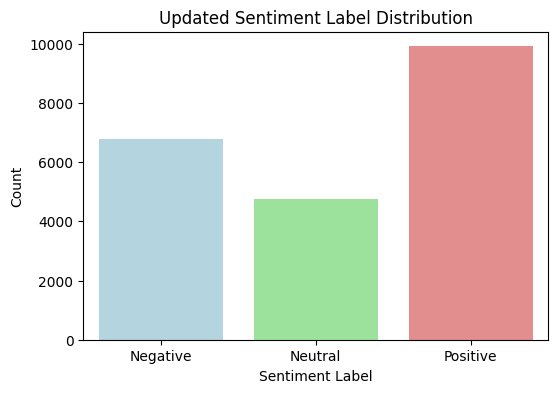

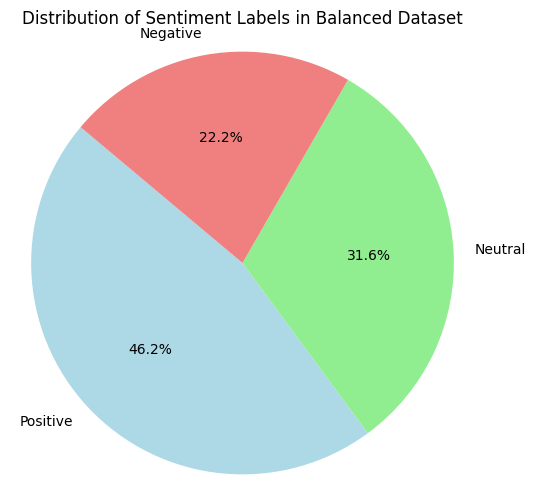

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Show the updated data size
print("Updated dataset size:", df_train_balanced.shape)
print("Label distribution after balancing:\n", df_train_balanced['label'].value_counts())

# Bar plot for label distribution
plt.figure(figsize=(6, 4))
sns.countplot(x="label", data=df_train_balanced, hue="label", legend=False,
              palette=['lightblue', 'lightgreen', 'lightcoral'])
plt.xticks(ticks=[0, 1, 2], labels=['Negative', 'Neutral', 'Positive'])
plt.xlabel("Sentiment Label")
plt.ylabel("Count")
plt.title("Updated Sentiment Label Distribution")
plt.show()

# Pie chart for label distribution
label_counts = df_train_balanced['label'].value_counts()
labels = ['Positive', 'Neutral', 'Negative']
colors = ['lightblue', 'lightgreen', 'lightcoral']

plt.figure(figsize=(6, 6))
plt.pie(label_counts, labels=labels, autopct='%1.1f%%', colors=colors, startangle=140)
plt.title("Distribution of Sentiment Labels in Balanced Dataset")
plt.axis('equal')
plt.show()



# Data Preprocessing


In [ ]:
!pip install nltk transformers indic-nlp-library


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.3/40.3 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.7/7.7 MB 48.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.1/121.1 kB 9.7 MB/s eta 0:00:00


In [ ]:
import re
import pandas as pd
import nltk
from nltk.corpus import stopwords
from indicnlp.tokenize import indic_tokenize
from transformers import AutoTokenizer


In [ ]:
nltk.download('stopwords')

# Load Bengali stopwords
stop_words = set(stopwords.words('bengali'))


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
# Use the balanced dataset
df = df_train_balanced.copy()

# Show a sample of the dataset before preprocessing
print(df[['Review', 'label']].head())  # Ensure the column name is correct


                                                  Review  label
41259  ফিলিস্তিন: বেচে থাকার লড়াই" বইটি মূলত ফিলিস্তি...      2
98859                                             ভাল বই      2
61956  ‘নজরের হেফাজত: সফলতার হাতিয়ার’ বইটির কলেবর যতট...      2
61644  খাঁটি তথ্য সহ তথ্যবহুল বই। লেখকের প্রভাবগুলি দ...      2
64923                                             ভালো       2


In [ ]:
# Function to clean Bengali text
def clean_text(text):
    text = str(text).strip().lower()  # Convert to lowercase & remove extra spaces
    text = re.sub(r'[a-zA-Z0-9]', '', text)  # Remove English words & numbers
    text = re.sub(r'[^\u0980-\u09FF\s]', '', text)  # Keep only Bengali characters
    text = re.sub(r'\s+', ' ', text).strip()  # Remove extra spaces
    return text

# Apply cleaning function to the 'Review' column
df['clean_sentence'] = df['Review'].apply(clean_text)

# Display cleaned text
print(df[['Review', 'clean_sentence']].head())



                                                  Review  \
41259  ফিলিস্তিন: বেচে থাকার লড়াই" বইটি মূলত ফিলিস্তি...   
98859                                             ভাল বই   
61956  ‘নজরের হেফাজত: সফলতার হাতিয়ার’ বইটির কলেবর যতট...   
61644  খাঁটি তথ্য সহ তথ্যবহুল বই। লেখকের প্রভাবগুলি দ...   
64923                                             ভালো    

                                          clean_sentence  
41259  ফিলিস্তিন বেচে থাকার লড়াই বইটি মূলত ফিলিস্তিনে...  
98859                                             ভাল বই  
61956  নজরের হেফাজত সফলতার হাতিয়ার বইটির কলেবর যতটা ছ...  
61644  খাঁটি তথ্য সহ তথ্যবহুল বই লেখকের প্রভাবগুলি দৃ...  
64923                                              ভালো  


In [ ]:
# Function to remove Bengali stopwords
def remove_stopwords(text):
    return " ".join([word for word in text.split() if word not in stop_words])

# Apply stopword removal
df['clean_sentence_ml'] = df['clean_sentence'].apply(remove_stopwords)

# Display after stopword removal
print(df[['Review', 'clean_sentence_ml']].head())



                                                  Review  \
41259  ফিলিস্তিন: বেচে থাকার লড়াই" বইটি মূলত ফিলিস্তি...   
98859                                             ভাল বই   
61956  ‘নজরের হেফাজত: সফলতার হাতিয়ার’ বইটির কলেবর যতট...   
61644  খাঁটি তথ্য সহ তথ্যবহুল বই। লেখকের প্রভাবগুলি দ...   
64923                                             ভালো    

                                       clean_sentence_ml  
41259  ফিলিস্তিন বেচে থাকার লড়াই বইটি মূলত ফিলিস্তিনে...  
98859                                             ভাল বই  
61956  নজরের হেফাজত সফলতার হাতিয়ার বইটির কলেবর ছোটো ব...  
61644  খাঁটি তথ্য তথ্যবহুল বই লেখকের প্রভাবগুলি দৃশ্যমান  
64923                                              ভালো  


In [ ]:
# Function for Indic NLP tokenization
def tokenize_text(text):
    return indic_tokenize.trivial_tokenize(text, lang="bn")

# Apply tokenization
df['tokenized_sentence'] = df['clean_sentence_ml'].apply(tokenize_text)

# Display tokenized dataset
print(df[['clean_sentence_ml', 'tokenized_sentence']].head(10))


                                        clean_sentence_ml  \
41259   ফিলিস্তিন বেচে থাকার লড়াই বইটি মূলত ফিলিস্তিনে...   
98859                                              ভাল বই   
61956   নজরের হেফাজত সফলতার হাতিয়ার বইটির কলেবর ছোটো ব...   
61644   খাঁটি তথ্য তথ্যবহুল বই লেখকের প্রভাবগুলি দৃশ্যমান   
64923                                               ভালো   
96616                                                 ভাল   
106185                                             সুন্দর   
76512                        বইটা ভালো পড়ে ভালো লাগার মতন   
78041                                                সেরা   
82082                                              সহায়ক   

                                       tokenized_sentence  
41259   [ফিলিস্তিন, বেচে, থাকার, লড়াই, বইটি, মূলত, ফিল...  
98859                                           [ভাল, বই]  
61956   [নজরের, হেফাজত, সফলতার, হাতিয়ার, বইটির, কলেবর,...  
61644   [খাঁটি, তথ্য, তথ্যবহুল, বই, লেখকের, প্রভাবগুলি...  
64923                       

In [ ]:
# Load Bangla BERT tokenizer
tokenizer = AutoTokenizer.from_pretrained("sagorsarker/bangla-bert-base")

# Function for Transformer-based tokenization
def transformer_tokenization(text):
    return tokenizer.encode_plus(
        text,
        add_special_tokens=True,
        max_length=128,
        padding='max_length',
        truncation=True,
        return_tensors="pt"
    )

# Apply Transformer-based tokenization
df['bert_tokenized'] = df['clean_sentence'].apply(lambda x: transformer_tokenization(x)['input_ids'].squeeze().tolist())

# Display final dataset with BERT tokenized sentences
print(df[['clean_sentence', 'bert_tokenized']].head(10))


                                           clean_sentence  \
41259   ফিলিস্তিন বেচে থাকার লড়াই বইটি মূলত ফিলিস্তিনে...   
98859                                              ভাল বই   
61956   নজরের হেফাজত সফলতার হাতিয়ার বইটির কলেবর যতটা ছ...   
61644   খাঁটি তথ্য সহ তথ্যবহুল বই লেখকের প্রভাবগুলি দৃ...   
64923                                               ভালো   
96616                                                 ভাল   
106185                                             সুন্দর   
76512                        বইটা ভালো পড়ে ভালো লাগার মতন   
78041                                                সেরা   
82082                                              সহায়ক   

                                           bert_tokenized  
41259   [101, 76570, 7034, 17219, 2566, 6068, 21545, 6...  
98859   [101, 5477, 2936, 102, 0, 0, 0, 0, 0, 0, 0, 0,...  
61956   [101, 7441, 2046, 17163, 9033, 8878, 14979, 10...  
61644   [101, 84080, 48431, 9294, 3169, 48431, 69734, ...  
64923   [101, 5477, 2094, 23

In [ ]:
from IPython.display import display

# Display 5 random rows from the dataset
display(df.sample(n=5, random_state=None))


,Rating,Review,sentiment,label,clean_sentence,clean_sentence_ml,tokenized_sentence,bert_tokenized
11152,5,বইটি খুব সুন্দর পাশাপাশি কাগজটিও দুর্দান্ত।,positive,2,বইটি খুব সুন্দর পাশাপাশি কাগজটিও দুর্দান্ত,বইটি সুন্দর পাশাপাশি কাগজটিও দুর্দান্ত,"[বইটি, সুন্দর, পাশাপাশি, কাগজটিও, দুর্দান্ত]","[101, 6204, 5356, 4282, 5391, 2046, 2335, 4659..."
55583,5,দরকারী একটা বই,positive,2,দরকারী একটা বই,দরকারী একটা বই,"[দরকারী, একটা, বই]","[101, 49903, 2157, 2936, 102, 0, 0, 0, 0, 0, 0..."
95108,5,"স্যারের উক্তিগুলো মন্ত্রের মত কাজ করে, স্যারের...",positive,2,স্যারের উক্তিগুলো মন্ত্রের মত কাজ করে স্যারের ...,স্যারের উক্তিগুলো মন্ত্রের মত স্যারের লেখা আজও...,"[স্যারের, উক্তিগুলো, মন্ত্রের, মত, স্যারের, লে...","[101, 3091, 14979, 2040, 7241, 81528, 64716, 2..."
107890,5,ami tader bolte chai jara gali dichen..Amra Ba...,positive,2,,,[],"[101, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."
35606,3,"গল্প গুলো একটু অন্য রকম, ভালোই লাগলো পড়তে.",neutral,1,গল্প গুলো একটু অন্য রকম ভালোই লাগলো পড়তে,গল্প গুলো একটু ভালোই লাগলো পড়তে,"[গল্প, গুলো, একটু, ভালোই, লাগলো, পড়তে]","[101, 18928, 5829, 13392, 2395, 50364, 5562, 9..."


In [ ]:

df.to_csv('/content/drive/My Drive/preprocessed_data_4138.csv', index=False)
